# AQI Predictor — Exploratory Data Analysis

Sanity check on the backfilled + live data in the Hopsworks feature group (`aqi_features`, v1) for Lahore, before building the training pipeline.

In [1]:
import sys
from pathlib import Path

# Notebook kernels run with this notebook's own folder as cwd; add the repo
# root so `feature_pipeline` (a sibling package) is importable.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")

from feature_pipeline.hopsworks_store import read_features_df

# Colors (validated categorical/sequential palette)
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
YELLOW = "#eda100"
MAGENTA = "#e87ba4"
GREEN = "#008300"
VIOLET = "#4a3aa7"
RED = "#e34948"
CATEGORICAL = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

In [2]:
df = read_features_df()
df = df.sort_values("timestamp").reset_index(drop=True)
print(df.shape)
df.head()

2026-07-26 16:51:34,696 INFO: Initializing external client


2026-07-26 16:51:34,698 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-26 16:51:38,165 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41084


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.98s) 
(2066, 19)


,city_name,timestamp,temp,feels_like,humidity,pressure,wind_speed,wind_deg,clouds,co,no,no2,o3,so2,pm2_5,pm10,nh3,dominant_pollutant,aqi
0,Lahore,2026-04-27 00:00:00+00:00,27.5,27.6,37,976,0.55,360,12,521.18,0.00,8.52,25.75,2.48,26.57,51.00,47.79,pm2_5,83
1,Lahore,2026-04-27 01:00:00+00:00,27.4,28.0,40,976,0.25,79,0,533.02,0.03,8.78,23.62,2.45,26.35,49.17,49.10,pm2_5,83
2,Lahore,2026-04-27 02:00:00+00:00,28.6,28.2,34,977,1.45,63,7,568.32,0.95,8.82,24.42,2.68,26.85,50.20,48.58,pm2_5,84
3,Lahore,2026-04-27 03:00:00+00:00,30.9,30.8,30,978,0.96,84,4,609.03,2.23,8.54,35.99,3.02,28.97,54.09,45.91,pm2_5,88
4,Lahore,2026-04-27 04:00:00+00:00,33.9,33.7,24,979,0.70,90,0,457.95,0.97,5.73,86.06,4.82,27.77,50.78,30.35,pm2_5,86


## Data quality checks

Before trusting this for training: any duplicate timestamps, missing hours, or null values?

In [3]:
null_counts = df.isnull().sum()
print("Nulls per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "none")

duplicate_timestamps = df["timestamp"].duplicated().sum()
print(f"\nDuplicate timestamps: {duplicate_timestamps}")

full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing_hours = full_range.difference(df["timestamp"])
print(f"Expected hourly rows: {len(full_range)} | Actual: {len(df)} | Missing hours: {len(missing_hours)}")

Nulls per column:
none

Duplicate timestamps: 0
Expected hourly rows: 2172 | Actual: 2066 | Missing hours: 107


## AQI over time

A single series over time — is there a visible trend, daily cycle, or any suspicious flat/stuck stretches?

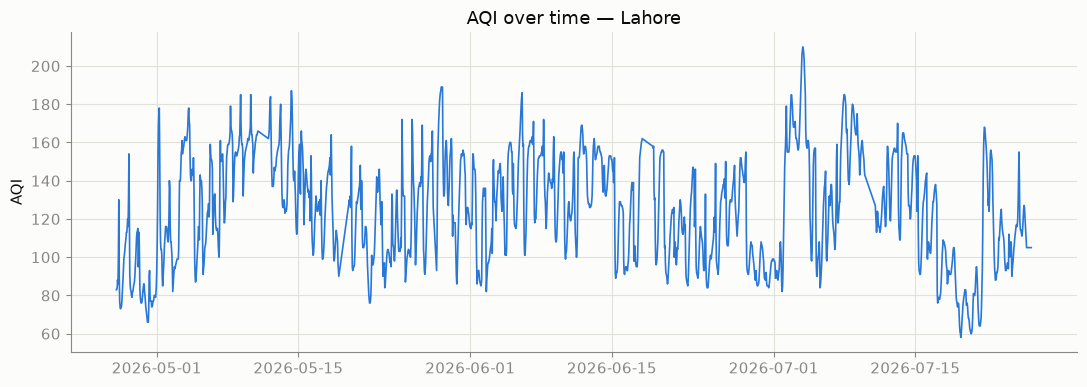

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["timestamp"], df["aqi"], color=BLUE, linewidth=1.2)
ax.set_title("AQI over time — Lahore")
ax.set_xlabel("")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.show()

## AQI distribution

Where does Lahore's air quality typically sit on the EPA 0–500 scale?

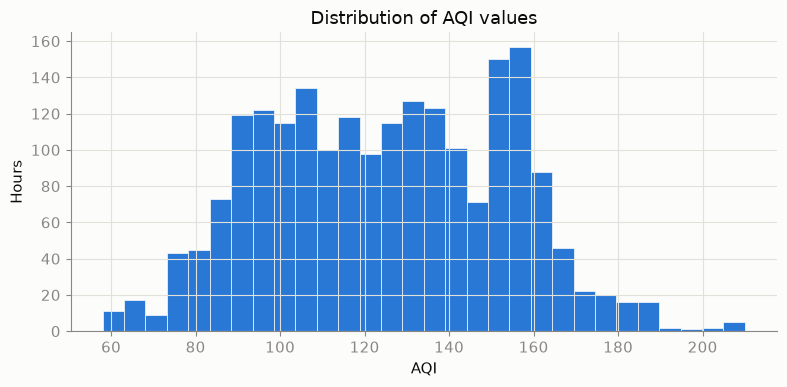

count    2066.000000
mean      124.848500
std        28.249044
min        58.000000
25%       102.000000
50%       125.000000
75%       150.000000
max       210.000000
Name: aqi, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["aqi"], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.set_title("Distribution of AQI values")
ax.set_xlabel("AQI")
ax.set_ylabel("Hours")
plt.tight_layout()
plt.show()

print(df["aqi"].describe())

## Which pollutant dominates AQI most often?

Recall the AQI is the max of the six per-pollutant sub-indices — which one wins most hours?

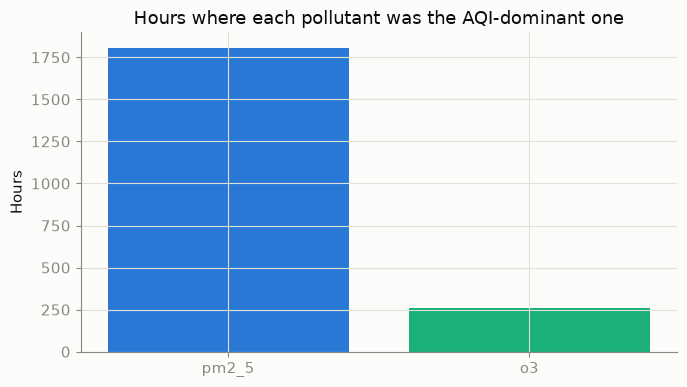

In [6]:
# Fixed color per pollutant identity (not by rank/frequency)
POLLUTANT_COLOR = {
    "pm2_5": BLUE,
    "pm10": ORANGE,
    "o3": AQUA,
    "co": YELLOW,
    "so2": MAGENTA,
    "no2": VIOLET,
}

counts = df["dominant_pollutant"].value_counts()
colors = [POLLUTANT_COLOR.get(p, MUTED) for p in counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=colors)
ax.set_title("Hours where each pollutant was the AQI-dominant one")
ax.set_ylabel("Hours")
plt.tight_layout()
plt.show()

## Correlation between features and AQI

Which weather/pollutant columns actually move with AQI? Useful sanity check before picking model inputs.

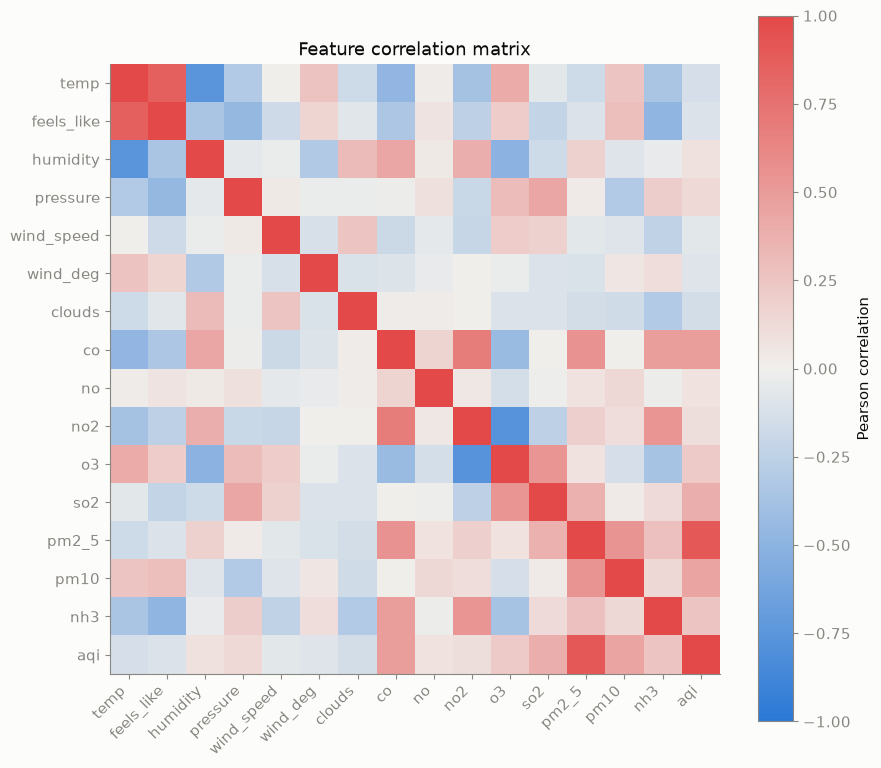

aqi           1.000000
pm2_5         0.895176
co            0.484072
pm10          0.446583
so2           0.383542
nh3           0.256881
o3            0.220314
pressure      0.130214
no2           0.100610
humidity      0.079214
no            0.075357
wind_speed   -0.065820
wind_deg     -0.091272
feels_like   -0.102288
temp         -0.126243
clouds       -0.142698
Name: aqi, dtype: float64


In [7]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = [
    "temp", "feels_like", "humidity", "pressure", "wind_speed", "wind_deg", "clouds",
    "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3", "aqi",
]
corr = df[numeric_cols].corr()

diverging = LinearSegmentedColormap.from_list("blue_gray_red", [BLUE, "#f0efec", RED])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print(corr["aqi"].sort_values(ascending=False))

## AQI by hour of day

Does AQI follow a daily rhythm (e.g. worse at night/rush hour)? Relevant since our target is a 3-day-ahead forecast.

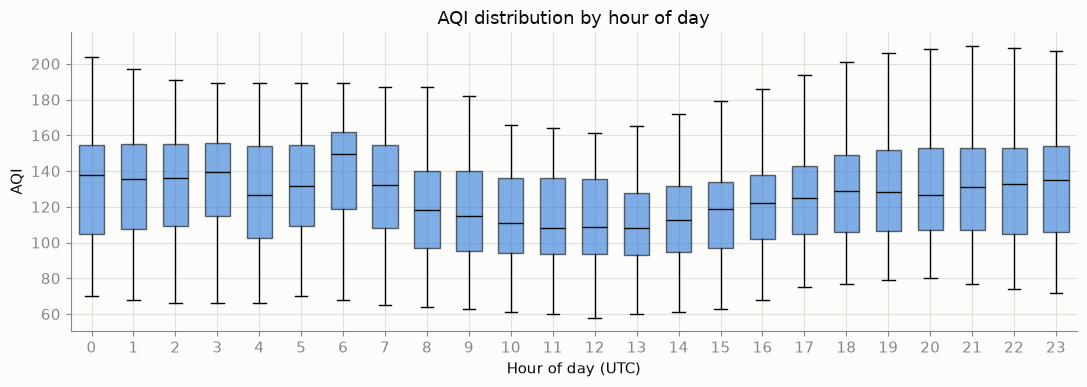

In [8]:
df["hour"] = df["timestamp"].dt.hour
by_hour = [df.loc[df["hour"] == h, "aqi"].values for h in range(24)]

fig, ax = plt.subplots(figsize=(11, 4))
box = ax.boxplot(by_hour, positions=range(24), patch_artist=True, widths=0.6, showfliers=False)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
    patch.set_edgecolor(INK)
for median in box["medians"]:
    median.set_color(INK)

ax.set_xticks(range(24))
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("AQI")
ax.set_title("AQI distribution by hour of day")
plt.tight_layout()
plt.show()